In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
raw_file = Path(
    r"C:\Users\rajia\Documents\Codex\2026-09-08\1-finance-branch-closure-early-warning\outputs\sba_7a_complete_fy_2020_2025.csv"
)

In [2]:
keep_columns = [
    "AsOfDate", "Program", "LocationID",
    "BorrCity", "BorrState", "BorrZip",
    "BankName", "BankState",
    "GrossApproval", "SBAGuaranteedApproval",
    "ApprovalDate", "ApprovalFY",
    "ProcessingMethod", "InitialInterestRate",
    "FixedorVariableInterestInd", "TermInMonths",
    "NaicsCode", "NaicsDescription",
    "ProjectCounty", "ProjectState",
    "SBADistrictOffice", "CongressionalDistrict",
    "BusinessType", "BusinessAge",
    "LoanStatus", "PaidInFullDate", "ChargeOffDate",
    "GrossChargeOffAmount", "JobsSupported",
    "CollateralInd", "SoldSecMrktInd"
]

text_columns = {
    "LocationID": "string",
    "BorrZip": "string",
    "NaicsCode": "string",
    "CongressionalDistrict": "string"
}

df = pd.read_csv(
    raw_file,
    usecols=keep_columns,
    dtype=text_columns,
    low_memory=False
)

print(df.shape)
df.head()

(388338, 31)


,AsOfDate,Program,LocationID,BorrCity,BorrState,BorrZip,BankName,BankState,GrossApproval,SBAGuaranteedApproval,...,CongressionalDistrict,BusinessType,BusinessAge,LoanStatus,PaidInFullDate,ChargeOffDate,GrossChargeOffAmount,JobsSupported,CollateralInd,SoldSecMrktInd
0,2026-06-30,7A,0029805,Norristown,PA,19403,"TD Bank, National Association",DE,25000.0,12500.0,...,04,PARTNERSHIP,Unanswered,P I F,2024-11-30,NaN,0.0,5.0,N,NaN
1,2026-06-30,7A,0084894,ASTORIA,NY,11102,"Santander Bank, National Association",DE,95800.0,47900.0,...,10,CORPORATION,Existing or more than 2 years old,P I F,2023-11-30,NaN,0.0,3.0,N,NaN
2,2026-06-30,7A,0053803,COLFAX,CA,95713,"U.S. Bank, National Association",OH,40000.0,20000.0,...,01,INDIVIDUAL,Unanswered,P I F,2024-11-30,NaN,0.0,0.0,Y,NaN
3,2026-06-30,7A,0123499,CIBOLO,TX,78108,BayFirst National Bank,FL,125000.0,106250.0,...,15,CORPORATION,Existing or more than 2 years old,EXEMPT,NaN,NaN,0.0,3.0,N,Y
4,2026-06-30,7A,0070400,HOUSTON,TX,77006,Golden Bank National Association,TX,250000.0,187500.0,...,02,CORPORATION,Unanswered,P I F,2024-01-31,NaN,0.0,4.0,Y,NaN


In [3]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 481


In [4]:
print("\nLoan status:")
print(df["LoanStatus"].value_counts())

print("\nApproval fiscal years:")
print(df["ApprovalFY"].value_counts().sort_index())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Loan status:
LoanStatus
EXEMPT    242061
P I F      68201
CANCLD     50104
COMMIT     21079
CHGOFF      6893
Name: count, dtype: int64

Approval fiscal years:
ApprovalFY
2020    42298
2021    51856
2022    47678
2023    57362
2024    70242
2025    78078
2026    40824
Name: count, dtype: int64

Missing values:
ChargeOffDate                 381450
PaidInFullDate                320136
SoldSecMrktInd                271574
BusinessAge                      186
BusinessType                      34
CongressionalDistrict             24
InitialInterestRate                8
FixedorVariableInterestInd         8
NaicsDescription                   0
CollateralInd                      0
dtype: int64


In [5]:
print(df["LoanStatus"])

0          P I F
1          P I F
2          P I F
3         EXEMPT
4          P I F
           ...  
388333    COMMIT
388334    COMMIT
388335    COMMIT
388336    COMMIT
388337    COMMIT
Name: LoanStatus, Length: 388338, dtype: object


In [6]:
# Remove extra spaces from text fields
for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = df[column].str.strip()

# Convert date columns to proper dates
date_columns = [
    "AsOfDate", "ApprovalDate",
    "PaidInFullDate", "ChargeOffDate"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

# Convert financial and numeric columns
numeric_columns = [
    "GrossApproval", "SBAGuaranteedApproval",
    "InitialInterestRate", "TermInMonths",
    "GrossChargeOffAmount", "JobsSupported"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["ApprovalFY"] = pd.to_numeric(
    df["ApprovalFY"], errors="coerce"
).astype("Int64")

In [7]:
starting_rows = len(df)

# Do not deduplicate after dropping source columns; that can merge distinct loans.
# The cleaned source already has the intended row grain, so retain all records.
duplicate_rows = int(df.duplicated().sum())
df = df.copy()

print("Rows before:", starting_rows)
print("Rows after:", len(df))
print("Exact duplicate rows detected (not removed):", duplicate_rows)


Rows before: 388338
Rows after: 387857
Duplicates removed: 481


In [8]:
# This is a new technical ID because the source does not provide a unique loan ID.
df.insert(0, "loan_record_id", range(1, len(df) + 1))

df["approval_year"] = df["ApprovalDate"].dt.year
df["approval_month"] = df["ApprovalDate"].dt.month
df["approval_quarter"] = df["ApprovalDate"].dt.quarter

df["guarantee_pct"] = (
    df["SBAGuaranteedApproval"] / df["GrossApproval"]
)

df["charge_off_flag"] = (
    df["LoanStatus"] == "CHGOFF"
).astype(int)

df["paid_in_full_flag"] = (
    df["LoanStatus"] == "P I F"
).astype(int)

df[[
    "GrossApproval", "SBAGuaranteedApproval",
    "guarantee_pct", "charge_off_flag", "paid_in_full_flag"
]].head(10)

,GrossApproval,SBAGuaranteedApproval,guarantee_pct,charge_off_flag,paid_in_full_flag
0,25000.0,12500.0,0.50,0,1
1,95800.0,47900.0,0.50,0,1
2,40000.0,20000.0,0.50,0,1
3,125000.0,106250.0,0.85,0,0
4,250000.0,187500.0,0.75,0,1
5,35000.0,17500.0,0.50,0,0
6,25000.0,12500.0,0.50,0,0
7,700000.0,525000.0,0.75,0,0
8,100000.0,50000.0,0.50,0,1
9,295500.0,221625.0,0.75,0,0


In [9]:
df["LoanStatus"].head(10)

0     P I F
1     P I F
2     P I F
3    EXEMPT
4     P I F
5    CANCLD
6    CANCLD
7    EXEMPT
8     P I F
9    EXEMPT
Name: LoanStatus, dtype: object

In [10]:
df_complete_years = df[
    df["ApprovalFY"].between(2020, 2025)
].copy()

print(df_complete_years["ApprovalFY"].value_counts().sort_index())
# Use the requested analysis population for all following summaries.
df = df[df["ApprovalFY"].between(2020, 2025)].copy()


ApprovalFY
2020    42191
2021    51737
2022    47609
2023    57317
2024    70199
2025    78009
Name: count, dtype: Int64


In [11]:
annual_summary = (
    df.groupby("ApprovalFY")
      .agg(
          loan_count=("loan_record_id", "count"),
          total_approval=("GrossApproval", "sum"),
          average_loan_amount=("GrossApproval", "mean"),
          charge_off_rate=("charge_off_flag", "mean"),
          paid_in_full_rate=("paid_in_full_flag", "mean")
      )
      .reset_index()
)

annual_summary["total_approval_billions"] = (
    annual_summary["total_approval"] / 1_000_000_000
)

annual_summary["charge_off_rate_pct"] = (
    annual_summary["charge_off_rate"] * 100
)

annual_summary.round(2)

,ApprovalFY,loan_count,total_approval,average_loan_amount,charge_off_rate,paid_in_full_rate,total_approval_billions,charge_off_rate_pct
0,2020,42191,2.252929e+10,533983.38,0.03,0.51,22.53,3.46
1,2021,51737,3.648214e+10,705146.02,0.02,0.38,36.48,2.47
2,2022,47609,2.567588e+10,539307.17,0.04,0.23,25.68,3.58
3,2023,57317,2.749524e+10,479704.86,0.03,0.14,27.50,3.03
4,2024,70199,3.111716e+10,443270.77,0.01,0.08,31.12,0.90
5,2025,78009,3.726979e+10,477762.68,0.00,0.03,37.27,0.11
6,2026,40795,2.183420e+10,535217.49,0.00,0.00,21.83,0.00


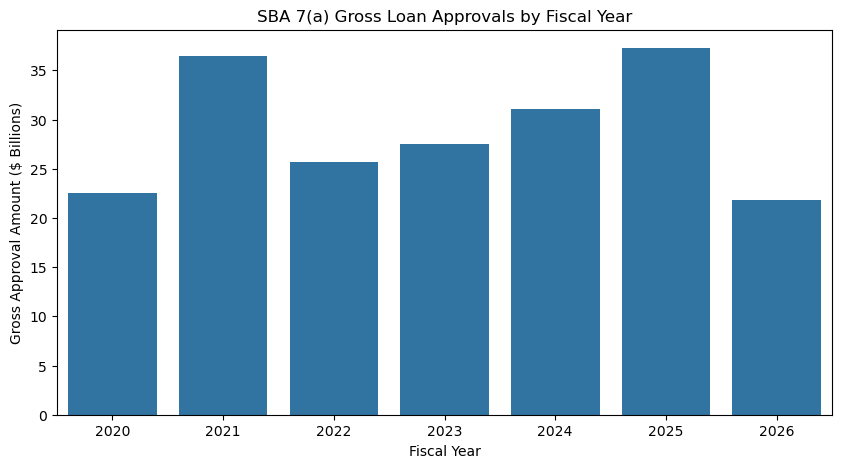

In [12]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=annual_summary,
    x="ApprovalFY",
    y="total_approval_billions",
    color="#1f77b4"
)

plt.title("SBA 7(a) Gross Loan Approvals by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Gross Approval Amount ($ Billions)")
plt.show()

In [13]:
state_summary = (
    df.groupby("BorrState")
      .agg(
          loan_count=("loan_record_id", "count"),
          total_approval=("GrossApproval", "sum"),
          average_loan=("GrossApproval", "mean"),
          charge_off_rate=("charge_off_flag", "mean")
      )
      .reset_index()
)

top_states = state_summary.nlargest(10, "total_approval")

top_states

,BorrState,loan_count,total_approval,average_loan,charge_off_rate
4,CA,45163,2.831052e+10,626851.965104,0.018356
45,TX,29641,2.169218e+10,731830.073209,0.018724
9,FL,28944,1.615936e+10,558297.391515,0.025152
35,NY,24147,8.953146e+09,370776.759018,0.033669
10,GA,11596,8.798836e+09,758782.028286,0.015005
15,IL,13378,7.115904e+09,531910.861115,0.016968
36,OH,21633,7.082708e+09,327402.935330,0.015486
50,WA,10768,6.293245e+09,584439.580238,0.011980
32,NJ,13237,6.246645e+09,471907.902093,0.027348
28,NC,8882,6.243010e+09,702883.382121,0.010583


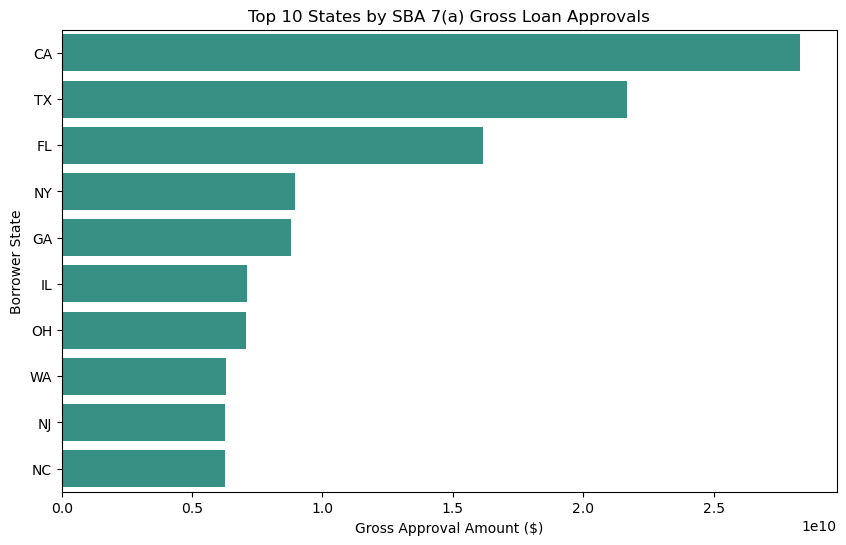

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    y="BorrState",
    x="total_approval",
    color="#2a9d8f"
)

plt.title("Top 10 States by SBA 7(a) Gross Loan Approvals")
plt.xlabel("Gross Approval Amount ($)")
plt.ylabel("Borrower State")
plt.show()

In [15]:
lender_summary = (
    df.groupby("BankName")
      .agg(
          loan_count=("loan_record_id", "count"),
          total_approval=("GrossApproval", "sum"),
          average_loan=("GrossApproval", "mean"),
          charge_off_rate=("charge_off_flag", "mean")
      )
      .reset_index()
)

top_lenders = lender_summary.nlargest(10, "total_approval")

top_lenders

,BankName,loan_count,total_approval,average_loan,charge_off_rate
1174,Live Oak Banking Company,10269,1.386925e+10,1.350594e+06,0.004577
1904,The Huntington National Bank,42834,1.101318e+10,2.571130e+05,0.016109
1324,"Newtek Bank, National Association",13745,5.680234e+09,4.132582e+05,0.000146
2011,"U.S. Bank, National Association",17855,4.415298e+09,2.472864e+05,0.025427
1550,"Readycap Lending, LLC",10384,4.369605e+09,4.208017e+05,0.009823
359,Celtic Bank Corporation,5813,3.919245e+09,6.742207e+05,0.013074
302,Byline Bank,2992,3.665989e+09,1.225264e+06,0.009358
2122,Wells Fargo Bank National Association,12009,3.387195e+09,2.820547e+05,0.053710
1325,"Newtek Small Business Finance, Inc.",4435,2.883363e+09,6.501383e+05,0.007666
1771,"TD Bank, National Association",17727,2.612028e+09,1.473474e+05,0.058498


In [16]:
industry_summary = (
    df.groupby("NaicsDescription")
      .agg(
          loan_count=("loan_record_id", "count"),
          total_approval=("GrossApproval", "sum"),
          average_loan=("GrossApproval", "mean")
      )
      .reset_index()
)

top_industries = industry_summary.nlargest(10, "total_approval")

top_industries

,NaicsDescription,loan_count,total_approval,average_loan
457,Hotels (except Casino Hotels) and Motels,5606,1.407202e+10,2.510171e+06
397,Full-Service Restaurants,18051,9.493990e+09,5.259537e+05
404,Gasoline Stations with Convenience Stores,4176,6.601240e+09,1.580757e+06
534,Limited-Service Restaurants,13057,6.153374e+09,4.712701e+05
666,Offices of Dentists,4413,4.026040e+09,9.123137e+05
170,Child Care Services,4042,3.127288e+09,7.736981e+05
359,Fitness and Recreational Sports Centers,7520,3.108440e+09,4.133564e+05
68,All Other Specialty Trade Contractors,6342,3.072674e+09,4.844961e+05
847,"Plumbing, Heating, and Air-Conditioning Contra...",6716,2.920816e+09,4.349041e+05
405,General Automotive Repair,5888,2.799345e+09,4.754322e+05


In [17]:
outcome_summary = (
    df.groupby("LoanStatus")
      .agg(
          loans=("loan_record_id", "count"),
          total_approval=("GrossApproval", "sum")
      )
      .reset_index()
)

outcome_summary["loan_share_pct"] = (
    outcome_summary["loans"] / outcome_summary["loans"].sum() * 100
)

outcome_summary.sort_values("loans", ascending=False)

,LoanStatus,loans,total_approval,loan_share_pct
3,EXEMPT,241958,1.332054e+11,62.383301
4,P I F,68143,3.697569e+10,17.569104
0,CANCLD,49798,2.333300e+10,12.839268
2,COMMIT,21065,7.748153e+09,5.431125
1,CHGOFF,6893,1.141439e+09,1.777201
